# MetaScore HPC — Nivel 3: Aceleración GPU con CUDA
## Proyecto: Optimización Paralela del Sistema de Scoring Metagenómico

**Asignatura:** Programación Concurrente y Distribuida 2026-I  
**Tecnología:** PyCUDA · CUDA C · NVIDIA T4 (Google Colab)  

---

### ¿Qué hace este notebook?

Implementa el **Nivel 3** del sistema MetaScore HPC: la búsqueda aleatoria del vector
de pesos óptimo **W\*** que maximiza el AUC, ejecutada en GPU mediante CUDA.

La idea central es que cada evaluación de un candidato **W** es **completamente
independiente** de las demás — no hay comunicación entre evaluaciones. Eso permite
asignar **un hilo CUDA por candidato** y evaluar miles simultáneamente.

### ¿Por qué Google Colab?

La máquina de desarrollo tiene una GPU **AMD Radeon integrada**. CUDA es tecnología
exclusiva de NVIDIA, por lo que el Nivel 3 no puede ejecutarse localmente.
Google Colab provee gratuitamente una GPU **NVIDIA T4**:

| Característica | NVIDIA T4 (Colab) |
|---|---|
| Núcleos CUDA | 2 560 |
| Memoria VRAM | 16 GB GDDR6 |
| Arquitectura | Turing (sm_75) |
| Costo | Gratuito |

### Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Configurar entorno GPU |
| 2 | Subir datos desde el PC local |
| 3A | Implementación con **PyCUDA** (Python + kernel CUDA) |
| 3B | Implementación con **CUDA C nativo** (compilación nvcc) |
| 4 | Análisis de resultados y métricas HPC |
| 5 | Exportar resultados al PC local |

---
## Sección 1 — Configurar el entorno GPU

> **Antes de ejecutar:** Ir a `Entorno de ejecución → Cambiar tipo de entorno de ejecución`
> y seleccionar **GPU T4**. Sin esto, todas las celdas CUDA fallarán.

La primera celda verifica qué GPU asignó Colab. `nvidia-smi` es la herramienta
estándar de NVIDIA para consultar el estado del driver y el hardware GPU.

In [ ]:
# Verificar que Colab asignó una GPU NVIDIA
# Si aparece 'No devices were found', cambiar el tipo de entorno de ejecución a GPU
!nvidia-smi

Thu Jun 18 17:54:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Instalación de PyCUDA


In [ ]:
# PyCUDA no viene preinstalado en Colab — se instala una sola vez por sesión
!pip install pycuda --quiet
print('PyCUDA instalado correctamente')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 12.0 MB/s eta 0:00:00
PyCUDA instalado correctamente


In [ ]:
import numpy as np
import time
import csv
import os
import subprocess
import matplotlib.pyplot as plt
from google.colab import files

import pycuda.autoinit          # inicializa el contexto CUDA con la GPU disponible
import pycuda.driver as cuda
from pycuda.compiler import SourceModule

# Constantes del dominio
N_SAMPLES = 10
N_HEALTHY  = 5
N_SICK     = 5

print('Entorno listo.')
print(f'PyCUDA versión: {pycuda.VERSION_TEXT}')

# Verificar que el contexto CUDA está activo
dev = cuda.Device(0)
print(f'GPU activa: {dev.name()}  |  VRAM: {dev.total_memory() // 1024**2} MB')

Entorno listo.
PyCUDA versión: 2026.1
GPU activa: Tesla T4  |  VRAM: 14912 MB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Sección 2 — Subir archivos de datos

Los datos se generaron localmente con `python data/generate_data.py`.
Deben subirse los archivos **binarios** (`.bin`) porque C y CUDA los leen
como arrays `float32`/`int32` crudos, sin encabezados.

Los archivos `.npy` también se suben para la parte PyCUDA (NumPy los carga directamente).

**Archivos requeridos** (están en la carpeta `data/` del proyecto local):

```
matrix_A.npy   matrix_A.bin
labels.npy     labels.bin
profile_T.npy  profile_T.bin
profile_S.npy  profile_S.bin
profile_F.npy  profile_F.bin
metadata.txt
```

In [ ]:
print('Selecciona todos los archivos de la carpeta data/ del proyecto local.')
print('Puedes seleccionar múltiples archivos a la vez con Ctrl+Click.\n')
uploaded = files.upload()
print(f'\nArchivos subidos: {list(uploaded.keys())}')

Selecciona todos los archivos de la carpeta data/ del proyecto local.
Puedes seleccionar múltiples archivos a la vez con Ctrl+Click.



Saving labels.bin to labels.bin
Saving labels.npy to labels.npy
Saving matrix_A.bin to matrix_A.bin
Saving matrix_A.npy to matrix_A.npy
Saving metadata.txt to metadata.txt
Saving profile_F.bin to profile_F.bin
Saving profile_F.npy to profile_F.npy
Saving profile_S.bin to profile_S.bin
Saving profile_S.npy to profile_S.npy
Saving profile_T.bin to profile_T.bin
Saving profile_T.npy to profile_T.npy

Archivos subidos: ['labels.bin', 'labels.npy', 'matrix_A.bin', 'matrix_A.npy', 'metadata.txt', 'profile_F.bin', 'profile_F.npy', 'profile_S.bin', 'profile_S.npy', 'profile_T.bin', 'profile_T.npy']


In [ ]:
# Leer dimensiones desde metadata.txt
with open('metadata.txt') as f:
    n_samples, n_items = map(int, f.read().split())

# Cargar datos en formato NumPy (para PyCUDA)
A = np.load('matrix_A.npy')    # (10, N)  float32
y = np.load('labels.npy')      # (10,)    int32
T = np.load('profile_T.npy')   # (N,)     float32
S = np.load('profile_S.npy')   # (N,)     float32
F = np.load('profile_F.npy')   # (N,)     float32

print(f'Dimensiones:')
print(f'  A : {A.shape}   dtype={A.dtype}')
print(f'  y : {y}         (0=sano, 1=enfermo)')
print(f'  T,S,F : {T.shape}  dtype={T.dtype}')
print(f'\nVerificación Dirichlet — suma fila 0 de A: {A[0].sum():.6f}  (debe ser 1.0)')

Dimensiones:
  A : (10, 50)   dtype=float32
  y : [0 0 0 0 0 1 1 1 1 1]         (0=sano, 1=enfermo)
  T,S,F : (50,)  dtype=float32

Verificación Dirichlet — suma fila 0 de A: 1.000000  (debe ser 1.0)


---
## Sección 3A — Implementación con PyCUDA

### Arquitectura de ejecución CUDA

CUDA organiza los hilos en una jerarquía de dos niveles:

```
Grid  (conjunto de bloques)
  └── Bloque  (conjunto de hilos que comparten memoria)
        └── Hilo  (unidad de ejecución mínima)
```

Para este problema:

```
K = 100 000 candidatos W

BLOCK_SIZE = 256 hilos por bloque
Grid size  = ceil(100 000 / 256) = 391 bloques

Total hilos activos = 391 × 256 = 100 096  ≥  K
   (los hilos con índice ≥ K se descartan con if gid >= K return)
```

Cada hilo recibe un **índice global** `gid = blockIdx.x * blockDim.x + threadIdx.x`
y evalúa exactamente el candidato **W_gid**.

### ¿Por qué BLOCK_SIZE = 256?

- Las GPUs NVIDIA ejecutan los hilos en grupos de **32 llamados warps**.
- 256 = 8 × 32 → múltiplo de warp, sin hilos desperdiciados.
- Es el valor estándar de la industria para kernels de propósito general.
- Valores menores (64, 128) reducen la ocupación; mayores (512, 1024) pueden
  limitar el número de bloques activos simultáneamente por restricciones de registro.

### Decisiones de diseño del kernel

| Decisión | Alternativa descartada | Por qué se eligió esta |
|---|---|---|
| **LCG de 64 bits** para números aleatorios | `cuRAND` (librería NVIDIA) | No requiere dependencia externa; cada hilo solo necesita 3 números → LCG es suficiente |
| **Método exponencial** para muestrear el símplex | Muestrear en host y transferir | Genera W directamente en GPU → cero transferencia de candidatos Host→Device |
| **Un hilo = un candidato** completo | Paralelizar la multiplicación A·P | Las 10 muestras son pocas; el cuello de botella es la cantidad de candidatos K |
| **Transferir A, T, S, F una sola vez** | Transferir por lotes | Los datos son pequeños (< 1 MB); transferir una vez minimiza latencia PCIe |
| **Reducción argmax en host** | Kernel de reducción en GPU | Con K ≤ 1M la reducción en CPU es < 1 ms; complejidad no justificada |

### Generador LCG

El LCG (Linear Congruential Generator) usa la recurrencia:

```
state_{n+1} = state_n × 6364136223846793005  +  1442695040888963407   (mod 2^64)
```

Los coeficientes son los mismos que usa Knuth. Cada hilo inicializa su estado
con `seed × tid` para garantizar secuencias **independientes por hilo**,
sin necesidad de comunicación entre hilos.

In [ ]:
# Código fuente del kernel CUDA (C escrito como string Python)
#
# Se usa r'''...''' (raw triple single-quote) para evitar conflictos de escape
# entre la sintaxis Python y los caracteres especiales del código C.
# PyCUDA compila este string con nvcc en tiempo de ejecución.

KERNEL_SOURCE = r'''
#define N_SAMPLES  10
#define N_HEALTHY   5
#define N_SICK      5

/* ── Generador LCG de 64 bits (thread-safe: estado privado por hilo) ───── */
__device__ float lcg_rand(unsigned long long *state) {
    *state = (*state * 6364136223846793005ULL) + 1442695040888963407ULL;
    return (float)((*state >> 33) & 0x7FFFFFFF) / (float)0x7FFFFFFF;
}

/* ── Muestreo del simplice {W1+W2+W3=1, Wi>=0} ─────────────────────────── */
/* Metodo: wi = -log(ui) / suma(-log(uj))  con ui ~ Uniforme(0,1)          */
__device__ void sample_simplex(float *w, unsigned long long *state) {
    float x[3], sum = 0.0f;
    for (int i = 0; i < 3; i++) {
        float u = lcg_rand(state);
        if (u < 1e-10f) u = 1e-10f;
        x[i]  = -logf(u);
        sum   += x[i];
    }
    for (int i = 0; i < 3; i++) w[i] = x[i] / sum;
}

/* ── Kernel principal: 1 hilo = 1 candidato W ───────────────────────────── */
__global__ void evaluate_candidates(
    int K, int n_items, unsigned int seed,
    const float * __restrict__ A,
    const float * __restrict__ T,
    const float * __restrict__ S,
    const float * __restrict__ F,
    const int   * __restrict__ labels,
    float *auc_out,
    float *w_out)
{
    int gid = blockIdx.x * blockDim.x + threadIdx.x;
    if (gid >= K) return;   /* hilos extra del ultimo bloque se descartan */

    /* Estado LCG unico por hilo: derivado de seed y gid */
    unsigned long long state =
        (unsigned long long)(seed + 1) * (unsigned long long)(gid + 1)
        * 6364136223846793005ULL;

    /* 1. Muestrear candidato W sobre el simplice */
    float w[3];
    sample_simplex(w, &state);

    /* 2. Calcular score por muestra: score_j = sum_i A[j,i] * P_i          */
    /*    P_i = w0*T[i] + w1*S[i] + w2*F[i]  (fusionado con el producto)   */
    float scores[N_SAMPLES];
    for (int j = 0; j < N_SAMPLES; j++) {
        float s = 0.0f;
        for (int i = 0; i < n_items; i++) {
            float P_i = w[0]*T[i] + w[1]*S[i] + w[2]*F[i];
            s += A[j * n_items + i] * P_i;
        }
        scores[j] = s;
    }

    /* 3. AUC via Mann-Whitney U: concordantes / (N_HEALTHY * N_SICK) */
    int concordant = 0;
    for (int i = 0; i < N_SAMPLES; i++) {
        if (labels[i] != 1) continue;
        for (int j = 0; j < N_SAMPLES; j++) {
            if (labels[j] != 0) continue;
            if (scores[i] > scores[j]) concordant++;
        }
    }

    /* 4. Escribir resultados en memoria global */
    auc_out[gid]       = (float)concordant / (float)(N_HEALTHY * N_SICK);
    w_out[gid * 3]     = w[0];
    w_out[gid * 3 + 1] = w[1];
    w_out[gid * 3 + 2] = w[2];
}
'''

# Compilar el kernel con nvcc
# options=['-O2']: optimización máxima sin depuración
mod    = SourceModule(KERNEL_SOURCE, options=['-O2'])
kernel = mod.get_function('evaluate_candidates')

print('Kernel compilado correctamente.')

Kernel compilado correctamente.


### Función de búsqueda en GPU

El flujo de la función `random_search_cuda` es:

```
1. Alocar buffers en device (d_A, d_T, d_S, d_F, d_labels, d_auc_out, d_w_out)
2. Transferir datos Host → Device  (una sola vez, antes del kernel)
3. Lanzar kernel  ←── aquí ocurre el cómputo paralelo y se mide el tiempo
4. Sincronizar: esperar a que todos los hilos terminen
5. Transferir resultados Device → Host
6. Reducción argmax en host con NumPy
```



In [ ]:
BLOCK_SIZE = 256   # múltiplo de warp (32); estándar para kernels generales

def random_search_cuda(K, A, T, S, F, y, seed=0):
    """
    Búsqueda aleatoria del W* que maximiza el AUC, ejecutada en GPU.

    Parametros
    ----------
    K : int         Número de candidatos a evaluar.
    A : ndarray     Matriz de contribución (10, N), float32.
    T, S, F : ndarray  Perfiles por ítem (N,), float32.
    y : ndarray     Etiquetas binarias (10,), int32.
    seed : int      Semilla aleatoria.

    Retorna
    -------
    (W_best, auc_best, elapsed_kernel_s, elapsed_total_s)
    """
    n_items = A.shape[1]
    grid    = (K + BLOCK_SIZE - 1) // BLOCK_SIZE

    # Asegurar tipos correctos (el kernel espera float32 e int32)
    A_c = np.ascontiguousarray(A, dtype=np.float32)
    T_c = np.ascontiguousarray(T, dtype=np.float32)
    S_c = np.ascontiguousarray(S, dtype=np.float32)
    F_c = np.ascontiguousarray(F, dtype=np.float32)
    y_c = np.ascontiguousarray(y, dtype=np.int32)

    t_total_start = time.perf_counter()

    # Transferir datos al device (una sola vez)
    d_A      = cuda.to_device(A_c)
    d_T      = cuda.to_device(T_c)
    d_S      = cuda.to_device(S_c)
    d_F      = cuda.to_device(F_c)
    d_labels = cuda.to_device(y_c)

    # Buffers de salida en device
    d_auc_out = cuda.mem_alloc(K * 4)          # K × float32
    d_w_out   = cuda.mem_alloc(K * 3 * 4)      # K × 3 × float32

    # Eventos CUDA para medir solo el tiempo del kernel
    ev_start = cuda.Event()
    ev_stop  = cuda.Event()

    ev_start.record()
    kernel(
        np.int32(K), np.int32(n_items), np.uint32(seed),
        d_A, d_T, d_S, d_F, d_labels,
        d_auc_out, d_w_out,
        block=(BLOCK_SIZE, 1, 1),
        grid=(grid, 1)
    )
    ev_stop.record()
    ev_stop.synchronize()   # esperar a que todos los hilos terminen

    elapsed_kernel_ms = ev_start.time_till(ev_stop)

    # Transferir resultados al host
    h_auc = np.empty(K, dtype=np.float32)
    h_w   = np.empty((K, 3), dtype=np.float32)
    cuda.memcpy_dtoh(h_auc, d_auc_out)
    cuda.memcpy_dtoh(h_w,   d_w_out)

    elapsed_total = time.perf_counter() - t_total_start

    # Reducción argmax en host
    best_idx = int(np.argmax(h_auc))
    W_best   = h_w[best_idx].copy()
    auc_best = float(h_auc[best_idx])

    return W_best, auc_best, elapsed_kernel_ms / 1000.0, elapsed_total


print('Función random_search_cuda definida.')

Función random_search_cuda definida.


In [ ]:
K    = 100_000
SEED = 0

print(f'[PyCUDA]  K={K:,}  BLOCK_SIZE={BLOCK_SIZE}  grid={( K + BLOCK_SIZE - 1) // BLOCK_SIZE}  n_items={n_items}')
print('Ejecutando kernel...\n')

W_best_gpu, auc_best_gpu, t_kernel, t_total = random_search_cuda(K, A, T, S, F, y, seed=SEED)

print(f'  W*           = [{W_best_gpu[0]:.4f}, {W_best_gpu[1]:.4f}, {W_best_gpu[2]:.4f}]')
print(f'  AUC          = {auc_best_gpu:.4f}')
print(f'  Tiempo kernel = {t_kernel:.6f} s  ({t_kernel*1000:.2f} ms)')
print(f'  Tiempo total  = {t_total:.4f} s  (incluye transferencias H↔D)')

[PyCUDA]  K=100,000  BLOCK_SIZE=256  grid=391  n_items=50
Ejecutando kernel...

  W*           = [0.9679, 0.0067, 0.0254]
  AUC          = 0.6800
  Tiempo kernel = 0.001317 s  (1.32 ms)
  Tiempo total  = 0.0066 s  (incluye transferencias H↔D)


## Sección 3B — CUDA C nativo (compilación con nvcc)

Además de PyCUDA, se compila y ejecuta el binario C directamente.
Esto permite:
- Verificar que ambas implementaciones producen el **mismo AUC** (validación cruzada).
- Medir el tiempo de la versión C pura sin overhead del intérprete Python.

In [ ]:
# Escribir scoring_kernel.cu al disco de Colab
# Se usa r'''...''' para que las comillas y backslashes del C no necesiten escape

cuda_c_source = r'''
#include <cuda_runtime.h>
#include <math.h>
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

#define BLOCK_SIZE  256
#define N_SAMPLES    10
#define N_HEALTHY     5
#define N_SICK        5
#define DATA_DIR    "."

#define CUDA_CHECK(call) do { \
    cudaError_t err = (call); \
    if (err != cudaSuccess) { \
        fprintf(stderr, "[CUDA] %s:%d %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(EXIT_FAILURE); \
    } \
} while(0)

static int read_metadata(int *ns, int *ni) {
    FILE *f = fopen("metadata.txt", "r");
    if (!f) { perror("metadata.txt"); return -1; }
    int r = fscanf(f, "%d %d", ns, ni);
    fclose(f); return (r == 2) ? 0 : -1;
}

static float *read_float_bin(const char *name, int count) {
    char path[256]; snprintf(path, sizeof(path), "%s/%s", DATA_DIR, name);
    FILE *f = fopen(path, "rb");
    if (!f) { perror(path); return NULL; }
    float *buf = (float *)malloc((size_t)count * sizeof(float));
    size_t n = fread(buf, sizeof(float), count, f);
    fclose(f); return (n == (size_t)count) ? buf : (free(buf), (float*)NULL);
}

static int *read_int_bin(const char *name, int count) {
    char path[256]; snprintf(path, sizeof(path), "%s/%s", DATA_DIR, name);
    FILE *f = fopen(path, "rb");
    if (!f) { perror(path); return NULL; }
    int *buf = (int *)malloc((size_t)count * sizeof(int));
    size_t n = fread(buf, sizeof(int), count, f);
    fclose(f); return (n == (size_t)count) ? buf : (free(buf), (int*)NULL);
}

__device__ float lcg_rand(unsigned long long *s) {
    *s = (*s * 6364136223846793005ULL) + 1442695040888963407ULL;
    return (float)((*s >> 33) & 0x7FFFFFFF) / (float)0x7FFFFFFF;
}

__device__ void sample_simplex(float *w, unsigned long long *s) {
    float x[3], sum = 0.0f;
    for (int i = 0; i < 3; i++) {
        float u = lcg_rand(s); if (u < 1e-10f) u = 1e-10f;
        x[i] = -logf(u); sum += x[i];
    }
    for (int i = 0; i < 3; i++) w[i] = x[i] / sum;
}

__global__ void evaluate_candidates(
    int K, int n_items, unsigned int seed,
    const float * __restrict__ A, const float * __restrict__ T,
    const float * __restrict__ S, const float * __restrict__ F,
    const int * __restrict__ labels, float *auc_out, float *w_out)
{
    int gid = blockIdx.x * blockDim.x + threadIdx.x;
    if (gid >= K) return;
    unsigned long long state =
        (unsigned long long)(seed+1) * (unsigned long long)(gid+1) * 6364136223846793005ULL;
    float w[3]; sample_simplex(w, &state);
    float scores[N_SAMPLES];
    for (int j = 0; j < N_SAMPLES; j++) {
        float s = 0.0f;
        for (int i = 0; i < n_items; i++) {
            float Pi = w[0]*T[i] + w[1]*S[i] + w[2]*F[i];
            s += A[j*n_items+i] * Pi;
        }
        scores[j] = s;
    }
    int c = 0;
    for (int i = 0; i < N_SAMPLES; i++) {
        if (labels[i] != 1) continue;
        for (int j = 0; j < N_SAMPLES; j++) {
            if (labels[j] != 0) continue;
            if (scores[i] > scores[j]) c++;
        }
    }
    auc_out[gid] = (float)c / (float)(N_HEALTHY*N_SICK);
    w_out[gid*3] = w[0]; w_out[gid*3+1] = w[1]; w_out[gid*3+2] = w[2];
}

static int argmax(const float *v, int n) {
    int idx = 0;
    for (int i = 1; i < n; i++) if (v[i] > v[idx]) idx = i;
    return idx;
}

int main(int argc, char *argv[]) {
    int K    = (argc > 1) ? atoi(argv[1]) : 100000;
    int seed = (argc > 2) ? atoi(argv[2]) : 0;
    int ns, ni;
    if (read_metadata(&ns, &ni) != 0) { fprintf(stderr, "metadata.txt no encontrado\n"); return 1; }
    float *A = read_float_bin("matrix_A.bin", ns*ni);
    float *T = read_float_bin("profile_T.bin", ni);
    float *S = read_float_bin("profile_S.bin", ni);
    float *F = read_float_bin("profile_F.bin", ni);
    int   *y = read_int_bin("labels.bin", ns);
    if (!A||!T||!S||!F||!y) { fprintf(stderr, "Error cargando datos\n"); return 1; }
    float *dA,*dT,*dS,*dF,*dauc,*dw; int *dlabels;
    CUDA_CHECK(cudaMalloc(&dA, (size_t)ns*ni*4));
    CUDA_CHECK(cudaMalloc(&dT, (size_t)ni*4));
    CUDA_CHECK(cudaMalloc(&dS, (size_t)ni*4));
    CUDA_CHECK(cudaMalloc(&dF, (size_t)ni*4));
    CUDA_CHECK(cudaMalloc(&dlabels, (size_t)ns*4));
    CUDA_CHECK(cudaMalloc(&dauc, (size_t)K*4));
    CUDA_CHECK(cudaMalloc(&dw,  (size_t)K*3*4));
    CUDA_CHECK(cudaMemcpy(dA, A, (size_t)ns*ni*4, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(dT, T, (size_t)ni*4,    cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(dS, S, (size_t)ni*4,    cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(dF, F, (size_t)ni*4,    cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(dlabels, y, (size_t)ns*4, cudaMemcpyHostToDevice));
    int grid = (K + BLOCK_SIZE - 1) / BLOCK_SIZE;
    printf("[CUDA C]  K=%d  grid=%d  block=%d  n_items=%d\n", K, grid, BLOCK_SIZE, ni);
    cudaEvent_t t0, t1; float ms = 0;
    CUDA_CHECK(cudaEventCreate(&t0)); CUDA_CHECK(cudaEventCreate(&t1));
    CUDA_CHECK(cudaEventRecord(t0));
    evaluate_candidates<<<grid, BLOCK_SIZE>>>(K, ni, (unsigned int)seed, dA,dT,dS,dF,dlabels,dauc,dw);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaEventRecord(t1)); CUDA_CHECK(cudaEventSynchronize(t1));
    CUDA_CHECK(cudaEventElapsedTime(&ms, t0, t1));
    float *hauc = (float*)malloc((size_t)K*4);
    float *hw   = (float*)malloc((size_t)K*3*4);
    CUDA_CHECK(cudaMemcpy(hauc, dauc, (size_t)K*4,   cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(hw,   dw,   (size_t)K*3*4, cudaMemcpyDeviceToHost));
    int bi = argmax(hauc, K);
    printf("  W*     = [%.4f, %.4f, %.4f]\n", hw[bi*3], hw[bi*3+1], hw[bi*3+2]);
    printf("  AUC    = %.4f\n", hauc[bi]);
    printf("  Tiempo = %.4f s\n", ms/1000.0f);
    free(A);free(T);free(S);free(F);free(y);free(hauc);free(hw);
    cudaFree(dA);cudaFree(dT);cudaFree(dS);cudaFree(dF);
    cudaFree(dlabels);cudaFree(dauc);cudaFree(dw);
    cudaEventDestroy(t0); cudaEventDestroy(t1);
    return 0;
}
'''

with open('scoring_kernel.cu', 'w') as f:
    f.write(cuda_c_source)

print('scoring_kernel.cu escrito en disco.')

scoring_kernel.cu escrito en disco.


In [ ]:
# Compilar con nvcc
# -O2: optimización nivel 2 (balance velocidad/tiempo de compilación)
# -arch=sm_75: arquitectura Turing de la T4 (compute capability 7.5)
# -Xcompiler -Wall: pasar -Wall al compilador C subyacente

result = subprocess.run(
    ['nvcc', '-O2', '-arch=sm_75', '-Xcompiler', '-Wall',
     'scoring_kernel.cu', '-o', 'scoring_cuda'],
    capture_output=True, text=True
)

if result.returncode == 0:
    print('Compilación exitosa: ./scoring_cuda')
else:
    print('Error de compilación:')
    print(result.stderr)

Compilación exitosa: ./scoring_cuda


In [ ]:
# Ejecutar el binario CUDA C y capturar la salida
result_c = subprocess.run(
    ['./scoring_cuda', str(K), str(SEED)],
    capture_output=True, text=True
)
print(result_c.stdout)

# Extraer tiempo del binario C para comparar con PyCUDA
t_cuda_c = None
for line in result_c.stdout.splitlines():
    if 'Tiempo' in line:
        t_cuda_c = float(line.split('=')[1].replace('s','').strip())

print(f'Tiempo CUDA C extraído: {t_cuda_c} s')

[CUDA C]  K=100000  grid=391  block=256  n_items=50
  W*     = [0.9679, 0.0067, 0.0254]
  AUC    = 0.6800
  Tiempo = 0.0008 s

Tiempo CUDA C extraído: 0.0008 s


---
## Sección 4 — Análisis de resultados y métricas HPC

Para calcular el **Speedup** y la **Eficiencia** se necesita el tiempo de referencia
de la implementación Python secuencial, obtenido localmente.

In [ ]:
T_PYTHON_SEQ =  166.9143   #tiempo obtenido localmente con python/sequential.py

print(f'Tiempo referencia Python secuencial: {T_PYTHON_SEQ:.4f} s')

Tiempo referencia Python secuencial: 166.9143 s


In [ ]:
# Calcular speedup y eficiencia para ambas versiones CUDA
# Para GPU: P es el número de hilos activos en el kernel
# La eficiencia GPU no se calcula con la fórmula E = S/P de CPU,
# sino que se reporta como referencia de aceleración absoluta.

results = {
    'PyCUDA (kernel)': t_kernel,
    'CUDA C (binario)': t_cuda_c,
}

print(f"{'Implementación':<25} {'Tiempo (s)':>12} {'Speedup':>10}")
print('-' * 50)
print(f"{'Python secuencial':<25} {T_PYTHON_SEQ:>12.4f} {'1.00':>10}")

for name, t in results.items():
    if t is not None:
        speedup = T_PYTHON_SEQ / t
        print(f'{name:<25} {t:>12.4f} {speedup:>10.2f}x')
    else:
        print(f'{name:<25} {"N/A":>12} {"N/A":>10}')

Implementación              Tiempo (s)    Speedup
--------------------------------------------------
Python secuencial             166.9143       1.00
PyCUDA (kernel)                 0.0013  126711.32x
CUDA C (binario)                0.0008  208642.88x


/tmp/ipykernel_12384/1649632731.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([scores_sanos, scores_enfermos],


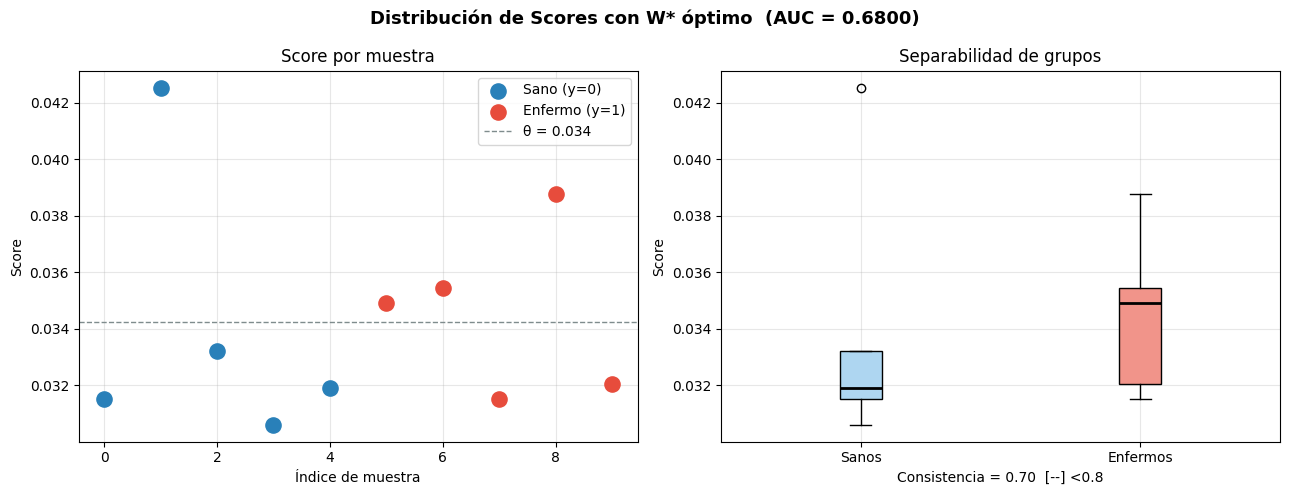

Gráfica guardada: score_distribution.png


In [ ]:
# Visualización 1: Distribución de scores con W* óptimo
#
# Muestra si el scoring separa correctamente los dos grupos.
# Un buen W* produce distribuciones bien separadas sin solapamiento.

P_best    = W_best_gpu[0]*T + W_best_gpu[1]*S + W_best_gpu[2]*F
scores_best = A @ P_best

scores_sanos    = scores_best[y == 0]
scores_enfermos = scores_best[y == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Distribución de Scores con W* óptimo  (AUC = {auc_best_gpu:.4f})',
             fontsize=13, fontweight='bold')

# Panel izquierdo: scatter plot
ax = axes[0]
ax.scatter(range(5),  scores_sanos,    color='#2980B9', s=120, zorder=3, label='Sano (y=0)')
ax.scatter(range(5,10), scores_enfermos, color='#E74C3C', s=120, zorder=3, label='Enfermo (y=1)')
ax.axhline(scores_best.mean(), color='#7F8C8D', linestyle='--', linewidth=1, label=f'θ = {scores_best.mean():.3f}')
ax.set_xlabel('Índice de muestra')
ax.set_ylabel('Score')
ax.set_title('Score por muestra')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel derecho: box plot
ax2 = axes[1]
bp = ax2.boxplot([scores_sanos, scores_enfermos],
                  labels=['Sanos', 'Enfermos'],
                  patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#AED6F1')
bp['boxes'][1].set_facecolor('#F1948A')
ax2.set_ylabel('Score')
ax2.set_title('Separabilidad de grupos')
ax2.grid(True, alpha=0.3)

# Anotar consistencia
theta  = float(scores_best.mean())
tp     = int(((scores_best > theta) & (y == 1)).sum())
tn     = int(((scores_best <= theta) & (y == 0)).sum())
consist = (tp / 5 + tn / 5)/2
ax2.set_xlabel(f'Consistencia = {consist:.2f}  {"[OK] ≥0.8" if consist >= 0.8 else "[--] <0.8"}')

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfica guardada: score_distribution.png')

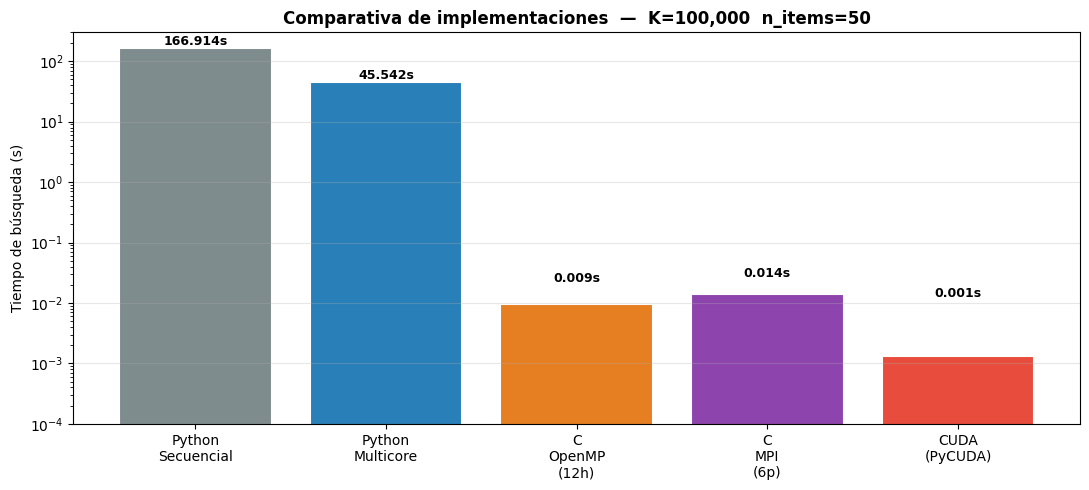

Gráfica guardada: comparativa_tiempos.png


In [ ]:
# Visualización 2: Comparativa de tiempos (todas las implementaciones)

tiempos = {
    'Python\nSecuencial':  T_PYTHON_SEQ,
    'Python\nMulticore':   45.5424,
    'C\nOpenMP\n(12h)':    0.0095,
    'C\nMPI\n(6p)':        0.0142,
    'CUDA\n(PyCUDA)':      t_kernel,
}

colores = ['#7F8C8D', '#2980B9', '#E67E22', '#8E44AD', '#E74C3C']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(tiempos.keys(), tiempos.values(), color=colores, edgecolor='white', linewidth=1.5)

for bar, t in zip(bars, tiempos.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{t:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Tiempo de búsqueda (s)')
ax.set_title(f'Comparativa de implementaciones  —  K={K:,}  n_items={n_items}', fontweight='bold')
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(bottom=1e-4)

plt.tight_layout()
plt.savefig('comparativa_tiempos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: comparativa_tiempos.png')

---
## Sección 5 — Exportar resultados al PC local

Se actualiza `benchmark.csv` con las filas correspondientes al Nivel 3 y
se descargan todos los archivos generados en esta sesión.

In [ ]:
# Agregar filas CUDA a benchmark.csv

csv_path = 'benchmark.csv'
header   = ['implementacion', 'K', 'n_items', 'tiempo_s', 'speedup', 'eficiencia', 'auc', 'nucleos']

file_exists = os.path.exists(csv_path) and os.path.getsize(csv_path) > 0

nuevas_filas = [
    [
        'CUDA_PyCUDA',
        K,
        n_items,
        round(t_kernel, 6),
        round(T_PYTHON_SEQ / t_kernel, 4),
        'N/A',
        round(auc_best_gpu, 4),
        'GPU_T4'
    ],
]

if t_cuda_c is not None:
    nuevas_filas.append([
        'CUDA_C',
        K,
        n_items,
        round(t_cuda_c, 6),
        round(T_PYTHON_SEQ / t_cuda_c, 4),
        'N/A',
        round(auc_best_gpu, 4),
        'GPU_T4'
    ])

with open(csv_path, 'a', newline='') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(header)
    writer.writerows(nuevas_filas)

print('benchmark.csv actualizado:')
with open(csv_path) as f:
    print(f.read())

benchmark.csv actualizado:
implementacion,K,n_items,tiempo_s,speedup,eficiencia,auc,nucleos
CUDA_PyCUDA,100000,50,0.001317,126711.3242,N/A,0.68,GPU_T4
CUDA_C,100000,50,0.0008,208642.875,N/A,0.68,GPU_T4



In [ ]:
# Descargar todos los archivos generados al PC local

archivos_a_descargar = [
    'benchmark.csv',
    'score_distribution.png',
    'comparativa_tiempos.png',
]

for archivo in archivos_a_descargar:
    if os.path.exists(archivo):
        print(f'Descargando {archivo}...')
        files.download(archivo)
    else:
        print(f'Archivo no encontrado: {archivo}')

print('\nDescarga completada.')
print('Copia el contenido de benchmark.csv a results/benchmark.csv en tu repositorio local.')

Descargando benchmark.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando score_distribution.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando comparativa_tiempos.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Descarga completada.
Copia el contenido de benchmark.csv a results/benchmark.csv en tu repositorio local.
